In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [45]:
df=pd.read_csv("C:\\Users\\harsh\\Downloads\\netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [46]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [47]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [33]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
genre           object
description     object
dtype: object

In [66]:
df["cast"] = df["cast"].bfill()
df["director"] = df["director"].ffill()
df["country"] = df["country"].ffill()
df["date_added"] = df["date_added"].ffill()
df["rating"] = df["rating"].ffill()
df["duration"] = df["duration"].ffill()


In [18]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [54]:
df.rename(columns={"listed_in": "genre"}, inplace=True)
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genre', 'description'],
      dtype='object')


In [27]:
duplicates = df[df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [show_id, type, title, director, cast, country, date_added, release_year, rating, duration, genre, description]
Index: []


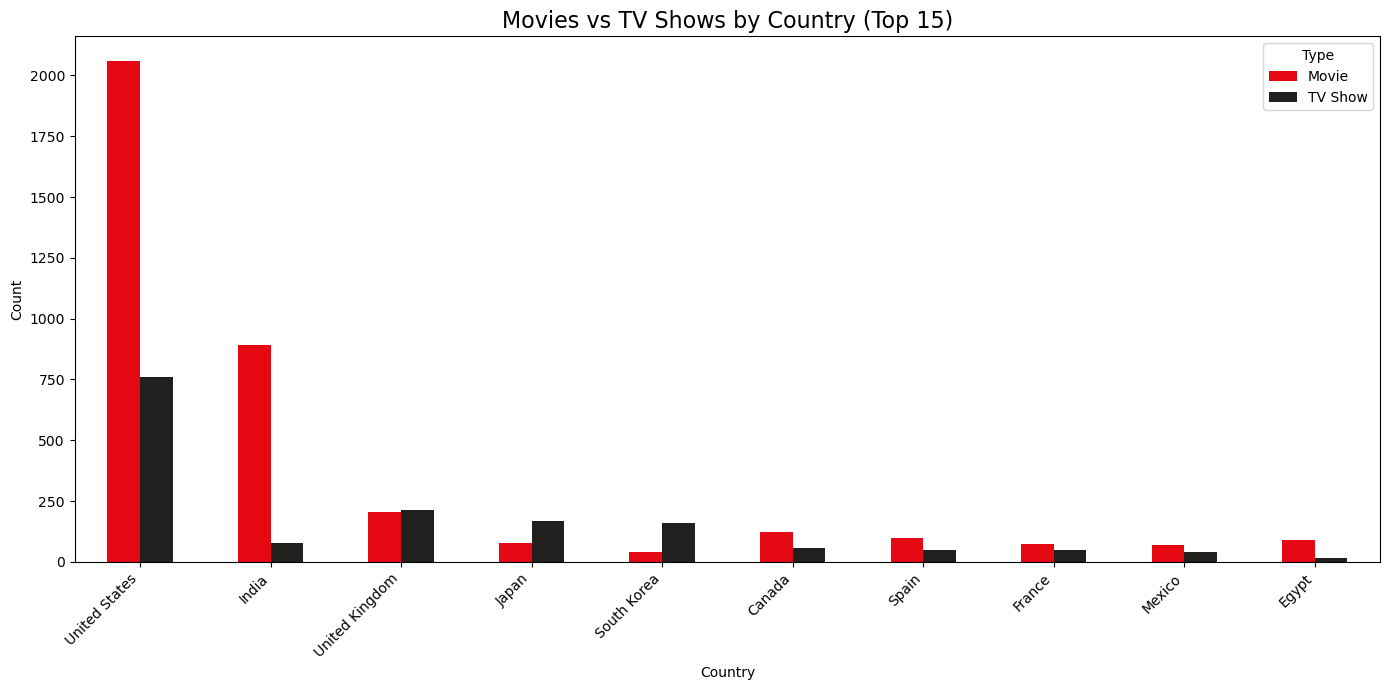

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# Count movies and TV shows per country
country_type = df.groupby(['country', 'type']).size().unstack(fill_value=0)

# Keep top 15 countries (by total count)
country_type['total'] = country_type.sum(axis=1)
country_type = country_type.nlargest(10, 'total').drop(columns='total')

# Plot
country_type.plot(kind='bar', figsize=(14, 7), color=['#E50914', '#221F1F'])

plt.title('Movies vs TV Shows by Country (Top 15)', fontsize=16)
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

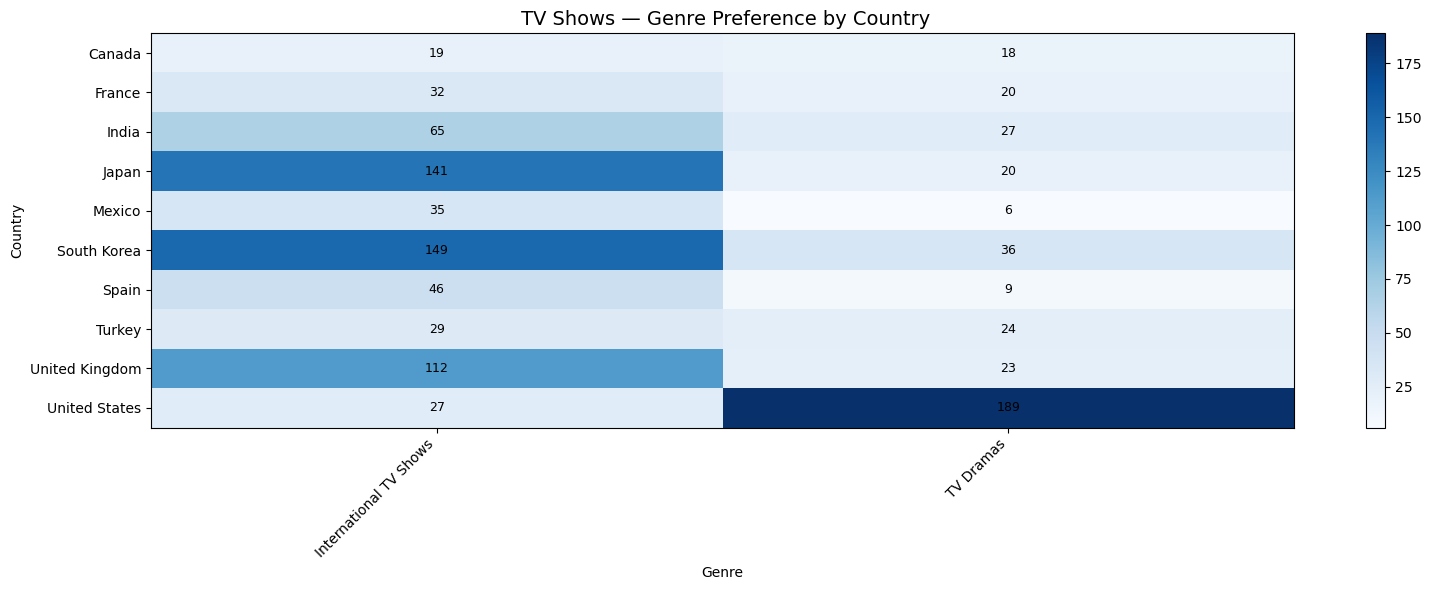

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Data Preparation ---
df['genre_split'] = df['genre'].str.split(',')
df_exploded = df.explode('genre_split')
df_exploded['genre_split'] = df_exploded['genre_split'].str.strip()

# Top 10 genres aur Top 10 countries
top_genres = df_exploded['genre_split'].value_counts().nlargest(10).index
top_countries = df_exploded['country'].value_counts().nlargest(10).index

df_filtered = df_exploded[
    (df_exploded['genre_split'].isin(top_genres)) & 
    (df_exploded['country'].isin(top_countries))
]

# --- TV Shows Only ---
tvshows = df_filtered[df_filtered['type'] == 'TV Show']
tv_pivot = tvshows.groupby(['country', 'genre_split']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(tv_pivot.values, cmap='Blues', aspect='auto')

ax.set_xticks(np.arange(len(tv_pivot.columns)))
ax.set_yticks(np.arange(len(tv_pivot.index)))
ax.set_xticklabels(tv_pivot.columns, rotation=45, ha='right')
ax.set_yticklabels(tv_pivot.index)

# Numbers dikhao andar
for i in range(len(tv_pivot.index)):
    for j in range(len(tv_pivot.columns)):
        ax.text(j, i, tv_pivot.values[i, j], ha='center', va='center', fontsize=9, color='black')

plt.colorbar(im, ax=ax)
plt.title(' TV Shows — Genre Preference by Country', fontsize=14)
plt.xlabel('Genre')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

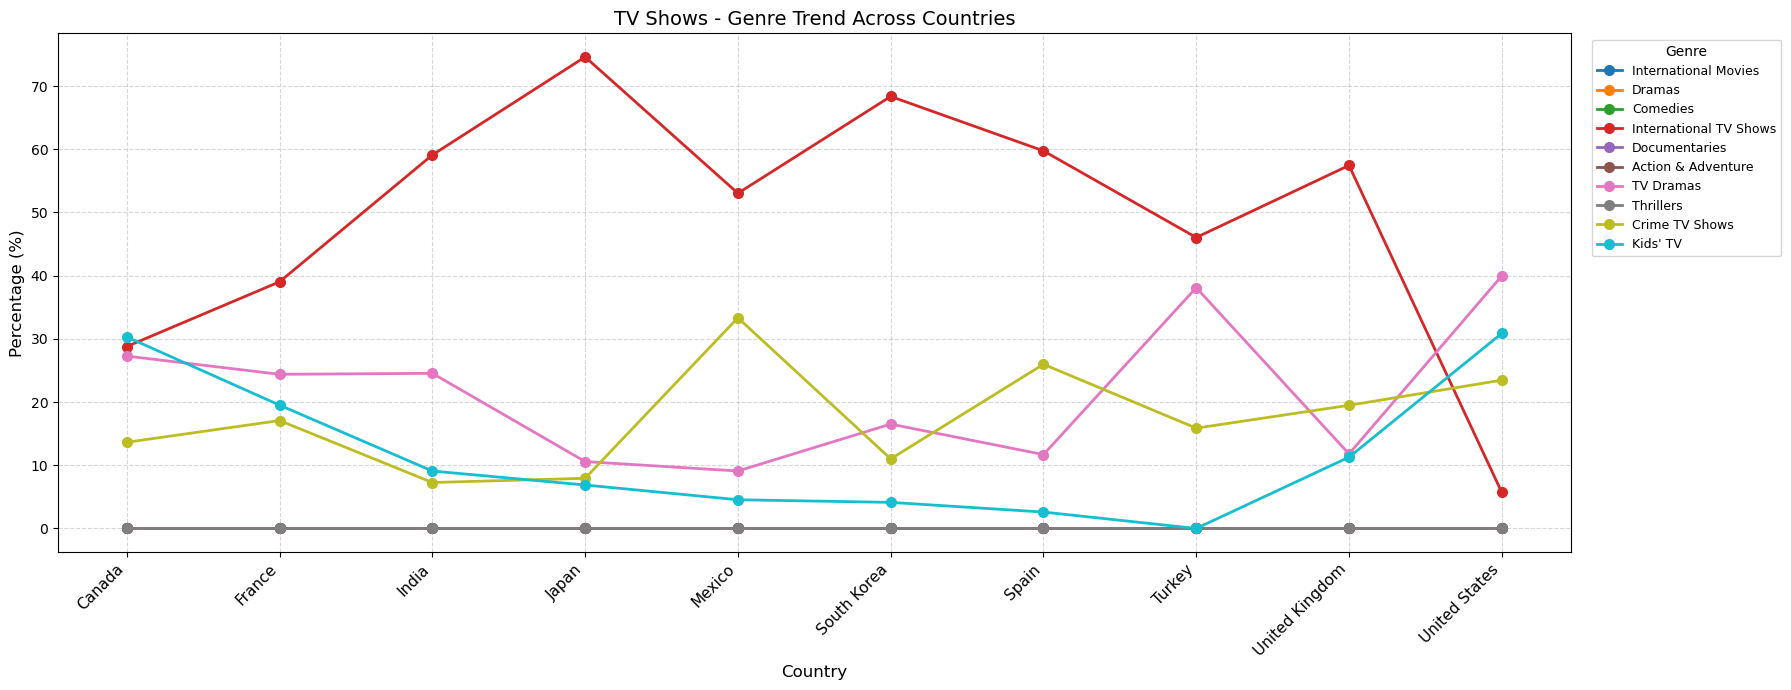

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Data Preparation ---
df['genre_split'] = df['genre'].str.split(',')
df_exploded = df.explode('genre_split')
df_exploded['genre_split'] = df_exploded['genre_split'].str.strip()

# Top genres
top_genres = [
    'International Movies', 'Dramas', 'Comedies',
    'International TV Shows', 'Documentaries',
    'Action & Adventure', 'TV Dramas', 'Thrillers',
    'Crime TV Shows', "Kids' TV"
]

# Top 10 countries
top_countries = df_exploded['country'].value_counts().nlargest(10).index

df_filtered = df_exploded[
    (df_exploded['genre_split'].isin(top_genres)) &
    (df_exploded['country'].isin(top_countries))
]

# TV Shows Only
tvshows = df_filtered[df_filtered['type'] == 'TV Show']
tv_pivot = tvshows.groupby(['country', 'genre_split']).size().unstack(fill_value=0)

# Ensure all genres
for g in top_genres:
    if g not in tv_pivot.columns:
        tv_pivot[g] = 0
tv_pivot = tv_pivot[top_genres]

# Percentage mein convert
tv_pivot_pct = tv_pivot.div(tv_pivot.sum(axis=1), axis=0) * 100

# --- Trend Line Graph ---
fig, ax = plt.subplots(figsize=(18, 7))

colors = plt.cm.tab10.colors
x = np.arange(len(tv_pivot_pct.index))  # countries

for i, genre in enumerate(tv_pivot_pct.columns):
    ax.plot(x, tv_pivot_pct[genre], 
            marker='o',          # circle marker
            linewidth=2, 
            markersize=7,
            label=genre, 
            color=colors[i % 10])

ax.set_xticks(x)
ax.set_xticklabels(tv_pivot_pct.index, rotation=45, ha='right', fontsize=11)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xlabel('Country', fontsize=12)
ax.set_title('TV Shows - Genre Trend Across Countries', fontsize=14)
ax.legend(title='Genre', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.5)  # grid lines for better readability
plt.tight_layout()
plt.show()

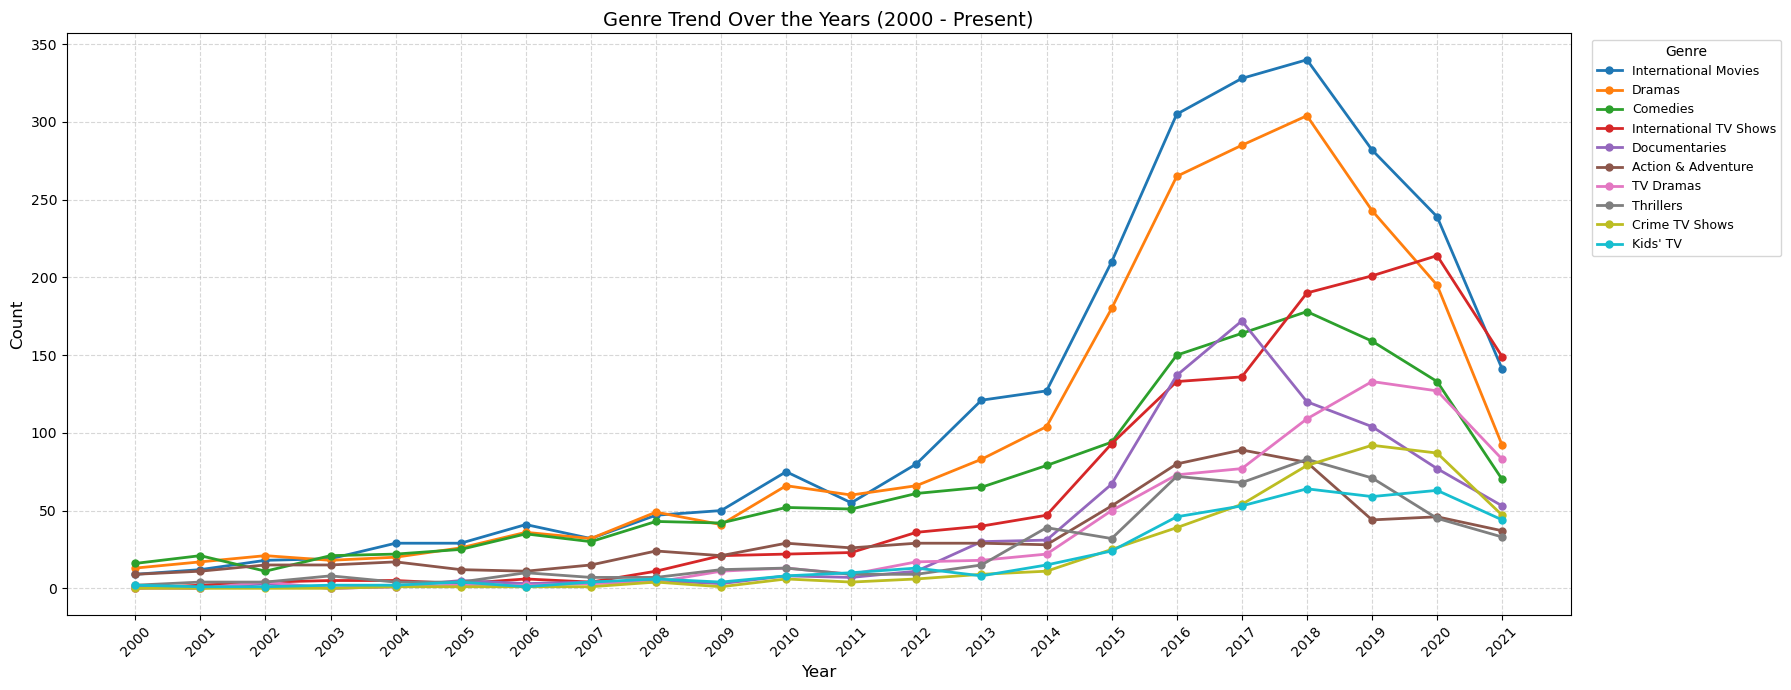

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Data Preparation ---
df['genre_split'] = df['genre'].str.split(',')
df_exploded = df.explode('genre_split')
df_exploded['genre_split'] = df_exploded['genre_split'].str.strip()

# Top 10 genres
top_genres = [
    'International Movies', 'Dramas', 'Comedies',
    'International TV Shows', 'Documentaries',
    'Action & Adventure', 'TV Dramas', 'Thrillers',
    'Crime TV Shows', "Kids' TV"
]

df_filtered = df_exploded[df_exploded['genre_split'].isin(top_genres)]

# Group by year and genre
year_genre = df_filtered.groupby(['release_year', 'genre_split']).size().unstack(fill_value=0)

# Sirf last 20 years dikhao
year_genre = year_genre[year_genre.index >= 2000]

# Ensure all genres
for g in top_genres:
    if g not in year_genre.columns:
        year_genre[g] = 0
year_genre = year_genre[top_genres]

# --- Plot ---
fig, ax = plt.subplots(figsize=(18, 7))

colors = plt.cm.tab10.colors

for i, genre in enumerate(year_genre.columns):
    ax.plot(year_genre.index, year_genre[genre],
            marker='o',
            linewidth=2,
            markersize=5,
            label=genre,
            color=colors[i % 10])

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Genre Trend Over the Years (2000 - Present)', fontsize=14)
ax.legend(title='Genre', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.5)
plt.xticks(year_genre.index, rotation=45)
plt.tight_layout()
plt.show()

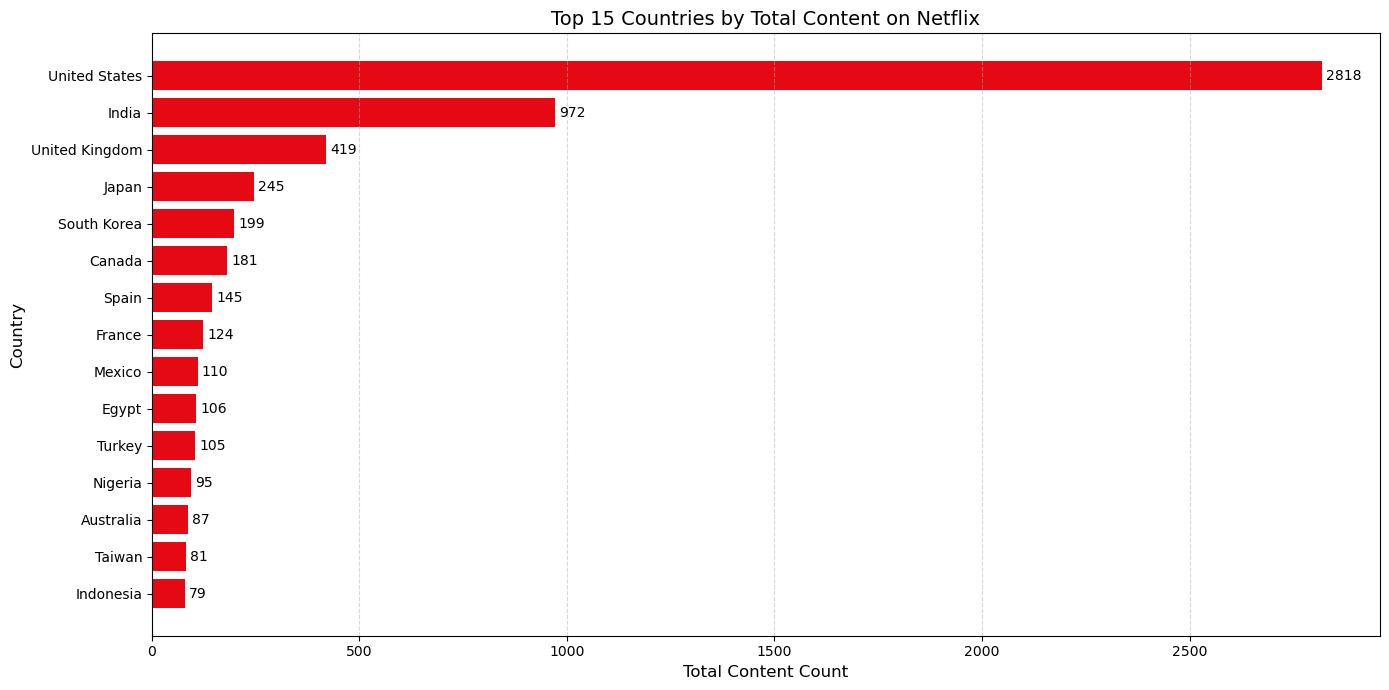

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# Count total content per country
country_content = df['country'].value_counts().nlargest(15)

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.barh(country_content.index[::-1], country_content.values[::-1], color='#E50914')

# Add value labels on bars
for bar, val in zip(bars, country_content.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)

ax.set_xlabel('Total Content Count', fontsize=12)
ax.set_ylabel('Country', fontsize=12)
ax.set_title('Top 15 Countries by Total Content on Netflix', fontsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

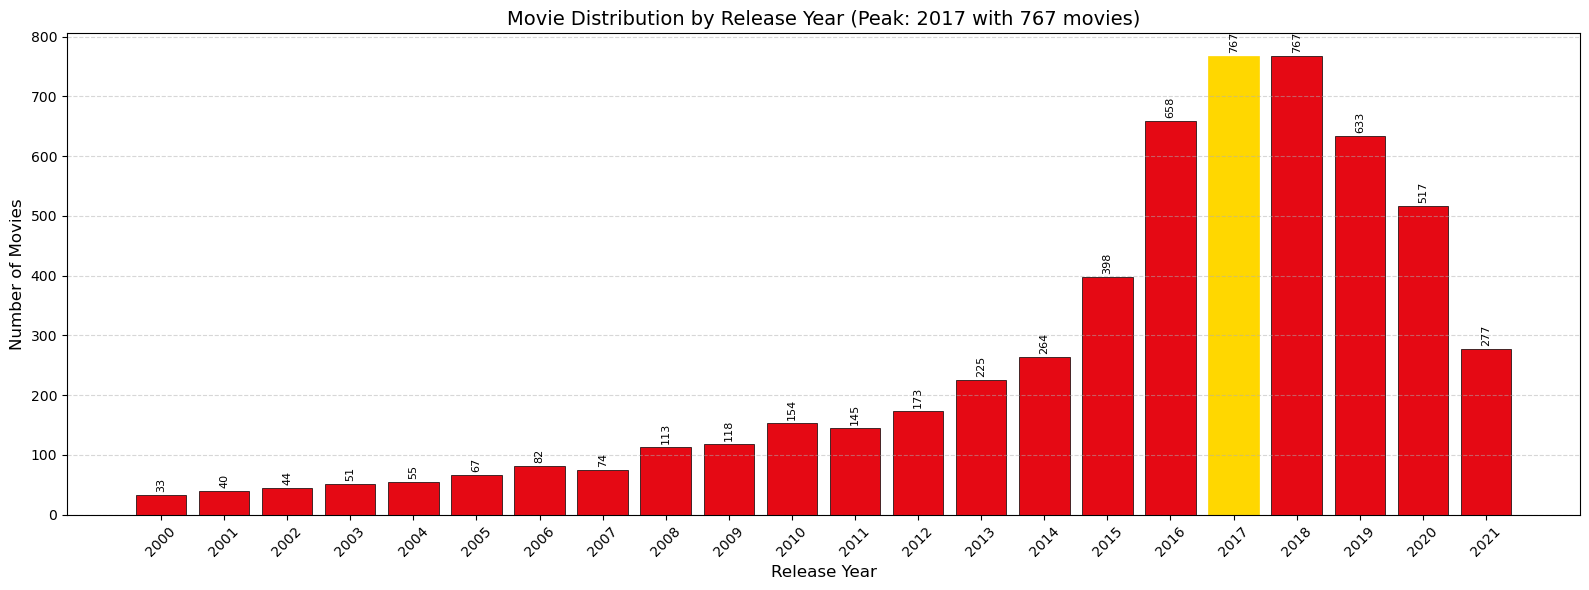

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter only Movies
movies = df[df['type'] == 'Movie']

# Count movies per year
year_counts = movies['release_year'].value_counts().sort_index()

# 2000 se baad ka data
year_counts = year_counts[year_counts.index >= 2000]

# --- Plot ---
fig, ax = plt.subplots(figsize=(16, 6))

bars = ax.bar(year_counts.index, year_counts.values, color='#E50914', edgecolor='black', linewidth=0.5)

# Highlight the peak year
peak_year = year_counts.idxmax()
peak_val = year_counts.max()

for bar, year in zip(bars, year_counts.index):
    if year == peak_year:
        bar.set_color('#FFD700')  # Gold color for peak year

# Add value on top of each bar
for bar, val in zip(bars, year_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=8, rotation=90)

ax.set_xlabel('Release Year', fontsize=12)
ax.set_ylabel('Number of Movies', fontsize=12)
ax.set_title(f'Movie Distribution by Release Year (Peak: {peak_year} with {peak_val} movies)', fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(year_counts.index, rotation=45)
plt.tight_layout()
plt.show()

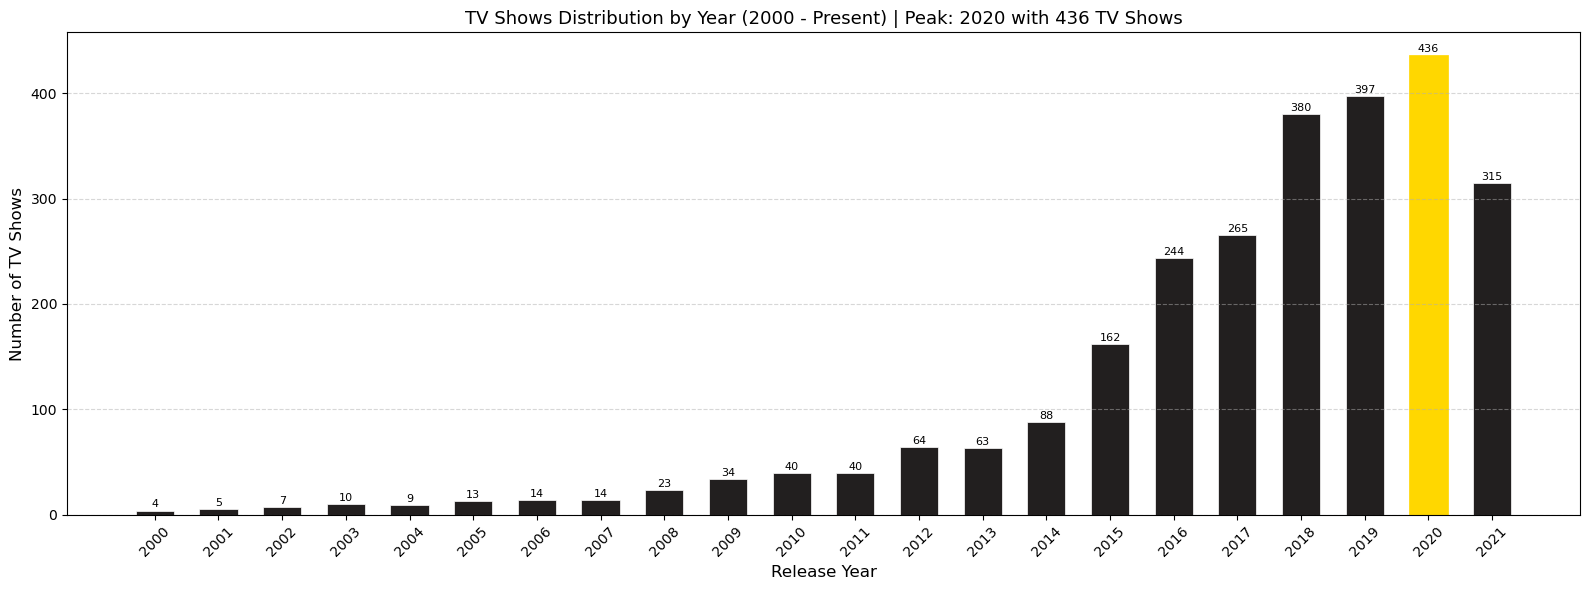

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Data Preparation ---
tvshows = df[df['type'] == 'TV Show'].copy()

# Count TV Shows per year
year_counts = tvshows['release_year'].value_counts().sort_index()

# 2000 se baad
year_counts = year_counts[year_counts.index >= 2000]

# Peak year
peak_year = year_counts.idxmax()
peak_val = year_counts.max()

# --- Plot ---
fig, ax = plt.subplots(figsize=(16, 6))

bars = ax.bar(year_counts.index, year_counts.values,
              color='#221F1F', edgecolor='white', linewidth=0.5, width=0.6)

# Gold color for peak year
for bar, year in zip(bars, year_counts.index):
    if year == peak_year:
        bar.set_color('#FFD700')

# Value on top of each bar
for bar, val in zip(bars, year_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=8, color='black')

ax.set_xlabel('Release Year', fontsize=12)
ax.set_ylabel('Number of TV Shows', fontsize=12)
ax.set_title(f'TV Shows Distribution by Year (2000 - Present) | Peak: {peak_year} with {peak_val} TV Shows', fontsize=13)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(year_counts.index, rotation=45)
plt.tight_layout()
plt.show()

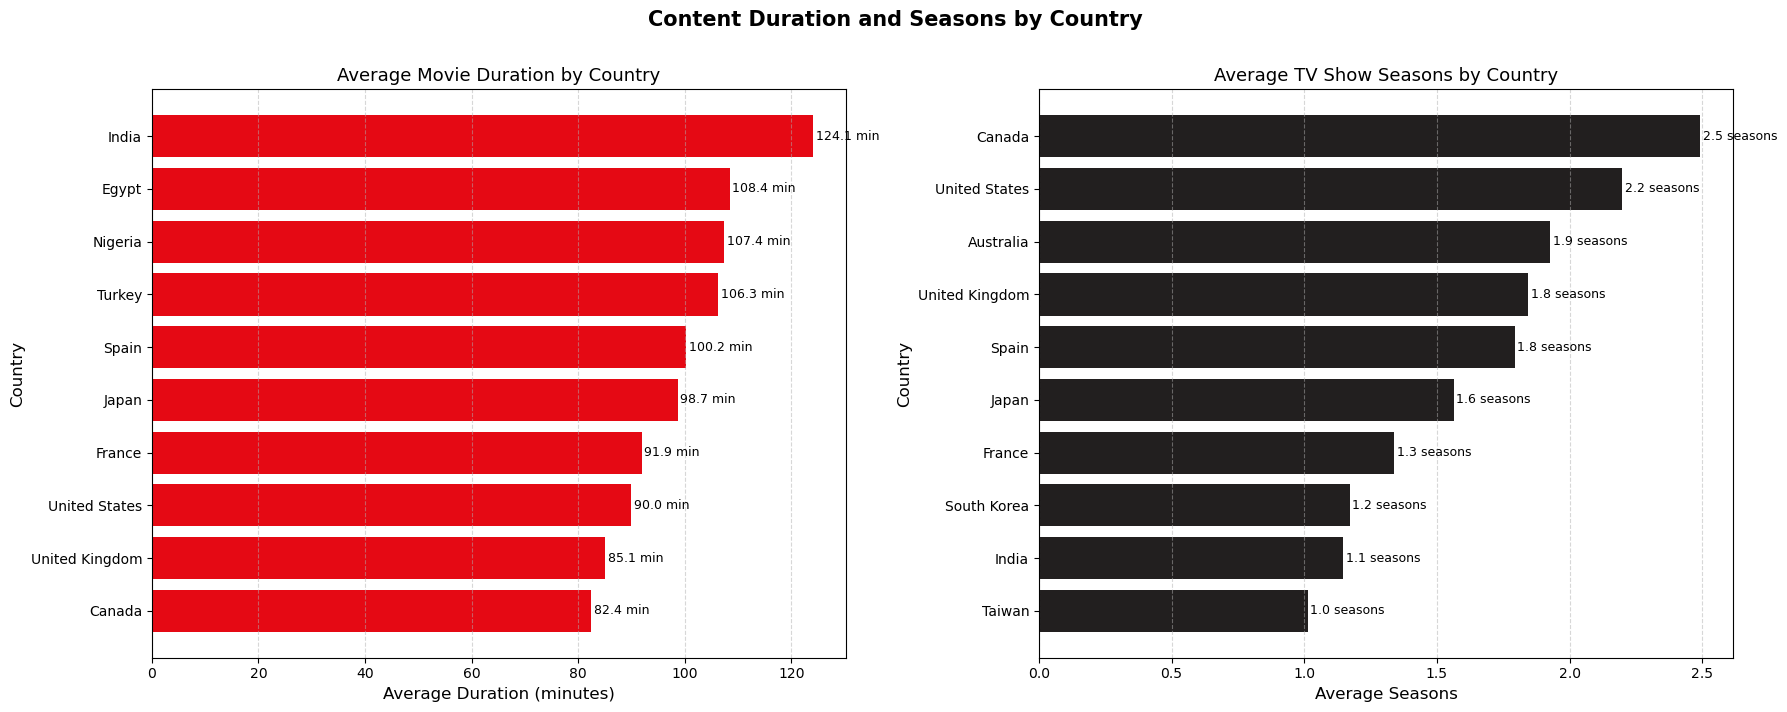

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Separate Movies and TV Shows ---
movies = df[df['type'] == 'Movie'].copy()
tvshows = df[df['type'] == 'TV Show'].copy()

# Extract numeric values
movies['minutes'] = movies['duration'].str.extract(r'(\d+)').astype(float)
tvshows['seasons'] = tvshows['duration'].str.extract(r'(\d+)').astype(float)

# Top 10 countries
top_countries_movies = movies['country'].value_counts().nlargest(10).index
top_countries_tv = tvshows['country'].value_counts().nlargest(10).index

# Filter
movies_filtered = movies[movies['country'].isin(top_countries_movies)]
tvshows_filtered = tvshows[tvshows['country'].isin(top_countries_tv)]

# Average duration per country
avg_minutes = movies_filtered.groupby('country')['minutes'].mean().sort_values(ascending=False)
avg_seasons = tvshows_filtered.groupby('country')['seasons'].mean().sort_values(ascending=False)

# --- Plot Side by Side ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- Graph 1: Movies - Avg Duration (minutes) ---
bars1 = ax1.barh(avg_minutes.index[::-1], avg_minutes.values[::-1], color='#E50914')

for bar, val in zip(bars1, avg_minutes.values[::-1]):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f} min', va='center', fontsize=9)

ax1.set_xlabel('Average Duration (minutes)', fontsize=12)
ax1.set_ylabel('Country', fontsize=12)
ax1.set_title('Average Movie Duration by Country', fontsize=13)
ax1.grid(axis='x', linestyle='--', alpha=0.5)

# --- Graph 2: TV Shows - Avg Seasons ---
bars2 = ax2.barh(avg_seasons.index[::-1], avg_seasons.values[::-1], color='#221F1F')

for bar, val in zip(bars2, avg_seasons.values[::-1]):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.1f} seasons', va='center', fontsize=9)

ax2.set_xlabel('Average Seasons', fontsize=12)
ax2.set_ylabel('Country', fontsize=12)
ax2.set_title('Average TV Show Seasons by Country', fontsize=13)
ax2.grid(axis='x', linestyle='--', alpha=0.5)

plt.suptitle('Content Duration and Seasons by Country', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

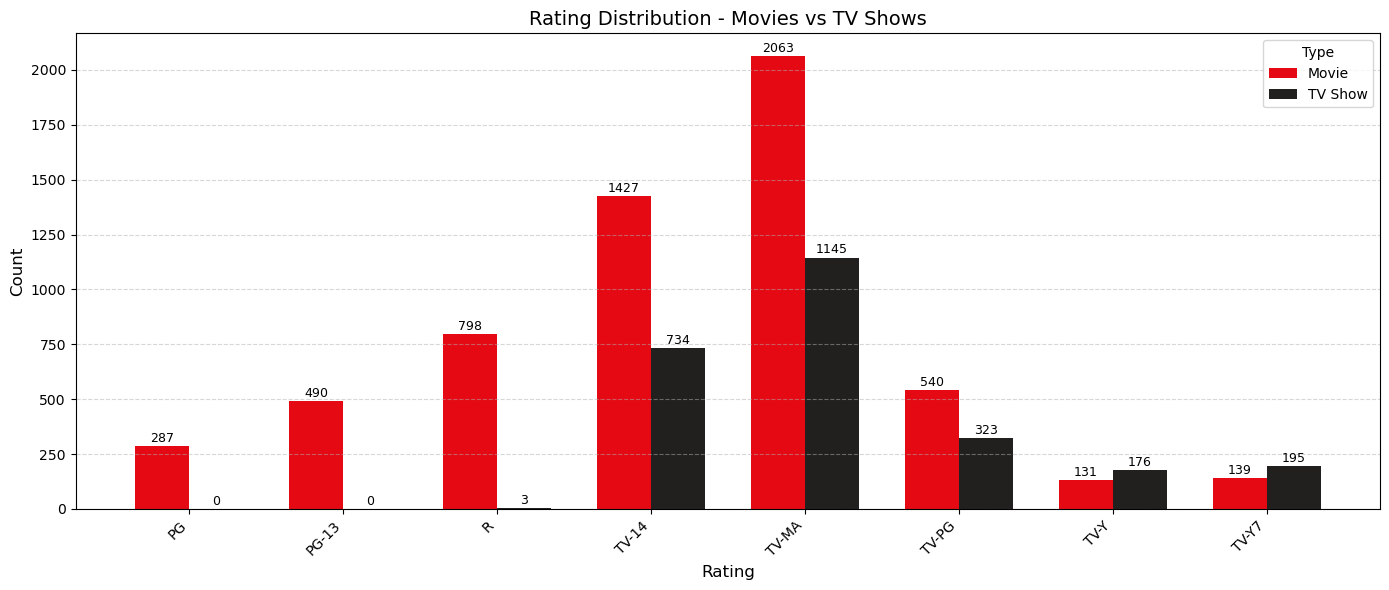

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Data Preparation ---
# Top ratings
top_ratings = df['rating'].value_counts().nlargest(8).index
df_filtered = df[df['rating'].isin(top_ratings)]

# Group by rating and type
rating_type = df_filtered.groupby(['rating', 'type']).size().unstack(fill_value=0)

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(rating_type.index))
width = 0.35
colors = ['#E50914', '#221F1F']

for i, col in enumerate(rating_type.columns):
    bars = ax.bar(x + i * width, rating_type[col],
                  width, label=col, color=colors[i])

    # Value on top
    for bar, val in zip(bars, rating_type[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(rating_type.index, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Count', fontsize=12)
ax.set_xlabel('Rating', fontsize=12)
ax.set_title('Rating Distribution - Movies vs TV Shows', fontsize=14)
ax.legend(title='Type', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()